<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 8.2: Working with Text
- Using [NLTK](http://www.nltk.org) (Natural Language Toolkit)
- Using [spaCy](https://spacy.io)

INSTRUCTIONS:
- Run the cells
- Observe and understand the results
- Answer the questions

## Import libraries

In [16]:
## Import Libraries
%matplotlib inline
import matplotlib.pyplot as plt
from collections import Counter

import regex as re
import spacy
import nltk

## Load data

In [2]:
## Loading the data
from google.colab import files
uploaded = files.upload()


input_file = 'ncc-1701-D.txt'

with open(input_file, 'r') as f:
    text = f.read()

Saving ncc-1701-D.txt to ncc-1701-D.txt


## Inspect the data

In [3]:
print(text[:1000])

USS Enterprise (NCC-1701-D)

"For five hundred years, every ship that has borne the name of the Enterprise has become a legend. This one is no different."

The USS Enterprise (NCC-1701-D) was a 24th century United Federation of Planets Galaxy Class starship operated by Starfleet, and the fifth Federation ship to bear the name Enterprise. During her career, the Enterprise served as the Federation flagship. The Enterprise was destroyed during the Battle of Veridian III in 2371.

==History==
===Construction and launch===
The Enterprise was built at Utopia Planitia Fleet Yards orbiting Mars in the Solar system. The construction was a massive undertaking, involving thousands of people across disciplines. Construction was supervised by Commander Orfil Quinteros. Dr. Leah Brahms was responsible for much of the Enterprise's warp propulsion system design. Some of the Enterprise's components were derived from technology originally developed on the USS Pegasus.

One of the ship's nacelle tube was

## Work the data
- if necessary or desired
    - remove text or content, e.g. quotes (") or metadata (===)
    - add content or markers, e.g. (#FLAG, --NAME--)
    - remove or convert special symbols, e.g. "é" to "e"
    - remove or convert emoticons

In [4]:
# ANSWER
def clean_with_regex(text):
    text = re.sub(r'"', '', text)                    # Remove quotes
    text = re.sub(r'=+', '', text)                   # Remove section headers like ===History===
    text = re.sub(r'\p{M}', '', text)                # Remove diacritics like é (combining marks)
    text = re.sub(r'[^\P{P}\n]+', '', text)          # Remove emojis/symbols/punctuation (optional)
    text = re.sub(r'[^\x00-\x7F]+', '', text)        # Remove non-ASCII characters
    text = re.sub(r'\s+', ' ', text).strip()         # Collapse multiple whitespaces
    return text

text_clean = clean_with_regex(text)
print(text_clean[:1000])


USS Enterprise NCC1701D For five hundred years every ship that has borne the name of the Enterprise has become a legend This one is no different The USS Enterprise NCC1701D was a 24th century United Federation of Planets Galaxy Class starship operated by Starfleet and the fifth Federation ship to bear the name Enterprise During her career the Enterprise served as the Federation flagship The Enterprise was destroyed during the Battle of Veridian III in 2371 History Construction and launch The Enterprise was built at Utopia Planitia Fleet Yards orbiting Mars in the Solar system The construction was a massive undertaking involving thousands of people across disciplines Construction was supervised by Commander Orfil Quinteros Dr Leah Brahms was responsible for much of the Enterprises warp propulsion system design Some of the Enterprises components were derived from technology originally developed on the USS Pegasus One of the ships nacelle tube was the site of a multiple murdersuicide whil

## Helper method

In [6]:
# create a bar chart of the frequency of the words in the text
def plot_words(tokens, top = 30):
    tokens_counter = Counter(tokens)
    tok = [t for (t, _) in tokens_counter.most_common()]
    val = [v for (_, v) in tokens_counter.most_common()]

    plt.figure(figsize = (16, 6))
    plt.bar(tok[:top], val[:top])
    plt.title('Number of terms: %d' % len(tokens_counter))
    plt.xticks(rotation = 90)

    plt.show()

## spaCy model invocation and text processing
spaCy does the processing of the text as part of the reading of the data.

In [7]:
# load spaCy and the English model
!python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm')

# process the text
doc = nlp(text)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 36.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Tokenise

In [8]:
# only show the results
# spaCy has done it already
for i, t in enumerate(doc):
    print('%2d| %r' % (i+1, t.text))
    if t.text == '.':
        break

 1| 'USS'
 2| 'Enterprise'
 3| '('
 4| 'NCC-1701'
 5| '-'
 6| 'D'
 7| ')'
 8| '\n\n'
 9| '"'
10| 'For'
11| 'five'
12| 'hundred'
13| 'years'
14| ','
15| 'every'
16| 'ship'
17| 'that'
18| 'has'
19| 'borne'
20| 'the'
21| 'name'
22| 'of'
23| 'the'
24| 'Enterprise'
25| 'has'
26| 'become'
27| 'a'
28| 'legend'
29| '.'


In [ ]:
# ANSWER

### Stop Words

In [9]:
## spaCy
print('i | with stop words without')
print('--| --------------- ------------')

# for all the tokens
for i, t in enumerate(doc):
    print('%2d| %-15r %r' % (i+1, t.text, ('' if t.is_stop else t.text)))

    # break after the first sentence
    if t.text == '.':
        break

i | with stop words without
--| --------------- ------------
 1| 'USS'           'USS'
 2| 'Enterprise'    'Enterprise'
 3| '('             '('
 4| 'NCC-1701'      'NCC-1701'
 5| '-'             '-'
 6| 'D'             'D'
 7| ')'             ')'
 8| '\n\n'          '\n\n'
 9| '"'             '"'
10| 'For'           ''
11| 'five'          ''
12| 'hundred'       ''
13| 'years'         'years'
14| ','             ','
15| 'every'         ''
16| 'ship'          'ship'
17| 'that'          ''
18| 'has'           ''
19| 'borne'         'borne'
20| 'the'           ''
21| 'name'          ''
22| 'of'            ''
23| 'the'           ''
24| 'Enterprise'    'Enterprise'
25| 'has'           ''
26| 'become'        ''
27| 'a'             ''
28| 'legend'        'legend'
29| '.'             '.'


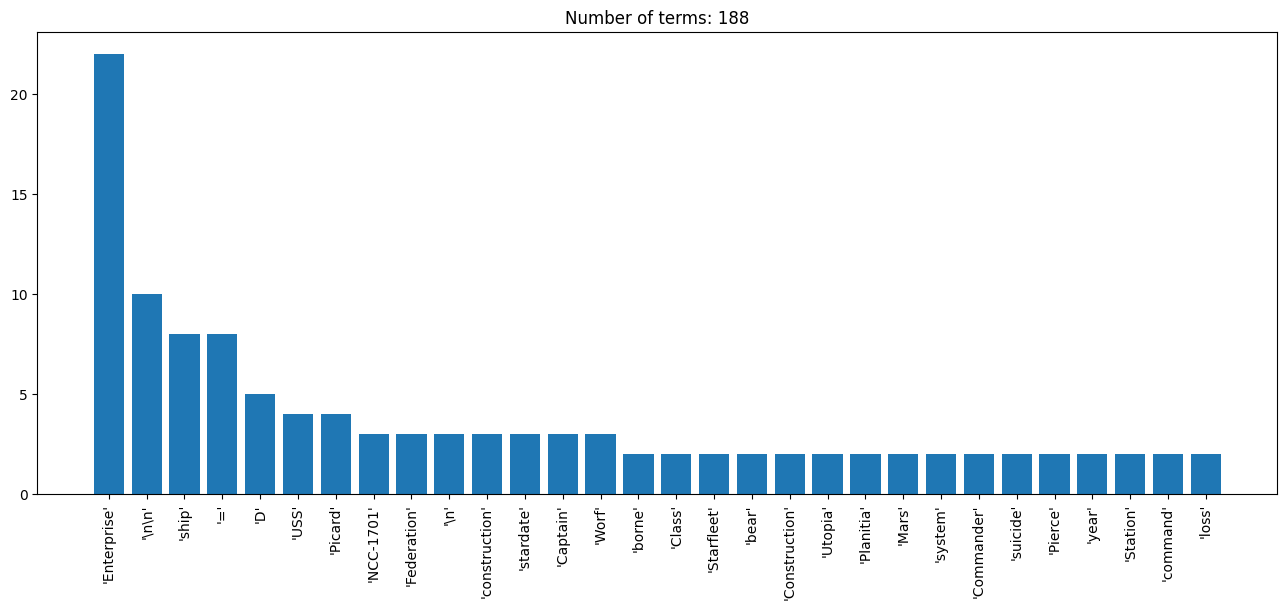

In [10]:
plot_words(['%r' % t.text for t in doc if not (t.is_stop | t.is_punct)])

### Check Part of Speech

In [11]:
## spaCy
for i, t in enumerate(doc):
    print('%2d|%-12r : %-5s %s' % (i+1, t.text, t.pos_, t.tag_))
    if t.text == '.':
        break

 1|'USS'        : PROPN NNP
 2|'Enterprise' : PROPN NNP
 3|'('          : PUNCT -LRB-
 4|'NCC-1701'   : PROPN NNP
 5|'-'          : PUNCT HYPH
 6|'D'          : NOUN  NN
 7|')'          : PUNCT -RRB-
 8|'\n\n'       : SPACE _SP
 9|'"'          : PUNCT ``
10|'For'        : ADP   IN
11|'five'       : NUM   CD
12|'hundred'    : NUM   CD
13|'years'      : NOUN  NNS
14|','          : PUNCT ,
15|'every'      : DET   DT
16|'ship'       : NOUN  NN
17|'that'       : PRON  WDT
18|'has'        : AUX   VBZ
19|'borne'      : VERB  VBN
20|'the'        : DET   DT
21|'name'       : NOUN  NN
22|'of'         : ADP   IN
23|'the'        : DET   DT
24|'Enterprise' : NOUN  NN
25|'has'        : AUX   VBZ
26|'become'     : VERB  VBN
27|'a'          : DET   DT
28|'legend'     : NOUN  NN
29|'.'          : PUNCT .


### Lemmatisation

In [12]:
## spaCy
print('i | Token        Lemma')
print('--| ------------ ------------')
for i, t in enumerate(doc):
    print('%2d| %-12r %r' % (i+1, t.text, t.lemma_))
    if t.text == '.':
        break

i | Token        Lemma
--| ------------ ------------
 1| 'USS'        'USS'
 2| 'Enterprise' 'Enterprise'
 3| '('          '('
 4| 'NCC-1701'   'NCC-1701'
 5| '-'          '-'
 6| 'D'          'd'
 7| ')'          ')'
 8| '\n\n'       '\n\n'
 9| '"'          '"'
10| 'For'        'for'
11| 'five'       'five'
12| 'hundred'    'hundred'
13| 'years'      'year'
14| ','          ','
15| 'every'      'every'
16| 'ship'       'ship'
17| 'that'       'that'
18| 'has'        'have'
19| 'borne'      'bear'
20| 'the'        'the'
21| 'name'       'name'
22| 'of'         'of'
23| 'the'        'the'
24| 'Enterprise' 'enterprise'
25| 'has'        'have'
26| 'become'     'become'
27| 'a'          'a'
28| 'legend'     'legend'
29| '.'          '.'


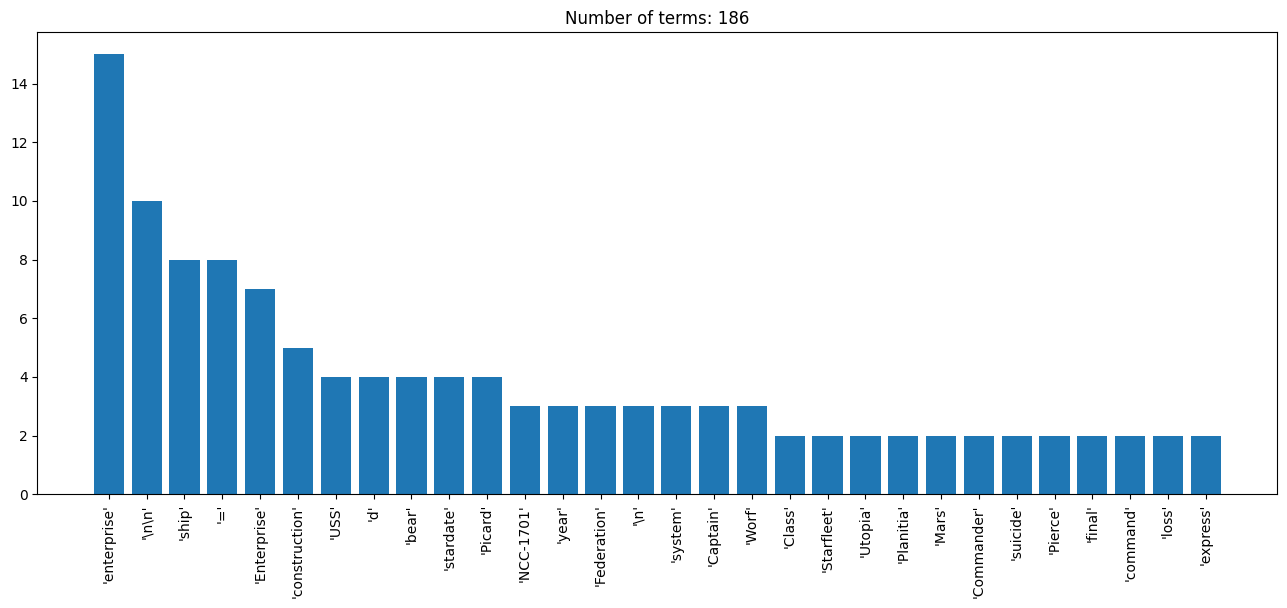

In [13]:
plot_words(['%r' % t.lemma_ for t in doc if not (t.is_stop | t.is_punct)])

### Entity Recognition

In [14]:
## spaCy
for i, s in enumerate(doc.sents):
    print('%2d: %s' % (i, re.sub(r'\n+', '', s.text)))
    if s.as_doc().ents:
        print('-'*80)
        for e in s.as_doc().ents:
            print('%-11s: %s' % (e.label_, re.sub(r'\n+', '', e.text)))
    print('='*80)

 0: USS Enterprise (NCC-1701-D)"For five hundred years, every ship that has borne the name of the Enterprise has become a legend.
--------------------------------------------------------------------------------
ORG        : USS Enterprise
DATE       : five hundred years
ORG        : Enterprise
 1: This one is no different.
 2: "The USS Enterprise (NCC-1701-D) was a 24th century United Federation of Planets Galaxy Class starship operated by Starfleet, and the fifth Federation ship to bear the name Enterprise.
--------------------------------------------------------------------------------
ORG        : The USS Enterprise
DATE       : a 24th century
ORG        : United Federation of Planets Galaxy
ORDINAL    : fifth
 3: During her career, the Enterprise served as the Federation flagship.
--------------------------------------------------------------------------------
ORG        : Enterprise
ORG        : Federation
 4: The Enterprise was destroyed during the Battle of Veridian III in 2371.

## Extra: Using NLTK for NLP

### Tokenise

In [18]:
nltk.download('punkt_tab')
# use nltk to find tokens
tokens = nltk.word_tokenize(text)

for i, t in enumerate(tokens[:25]):
    print('%2d| %r' % (i+1, t))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


 1| 'USS'
 2| 'Enterprise'
 3| '('
 4| 'NCC-1701-D'
 5| ')'
 6| "''"
 7| 'For'
 8| 'five'
 9| 'hundred'
10| 'years'
11| ','
12| 'every'
13| 'ship'
14| 'that'
15| 'has'
16| 'borne'
17| 'the'
18| 'name'
19| 'of'
20| 'the'
21| 'Enterprise'
22| 'has'
23| 'become'
24| 'a'
25| 'legend'


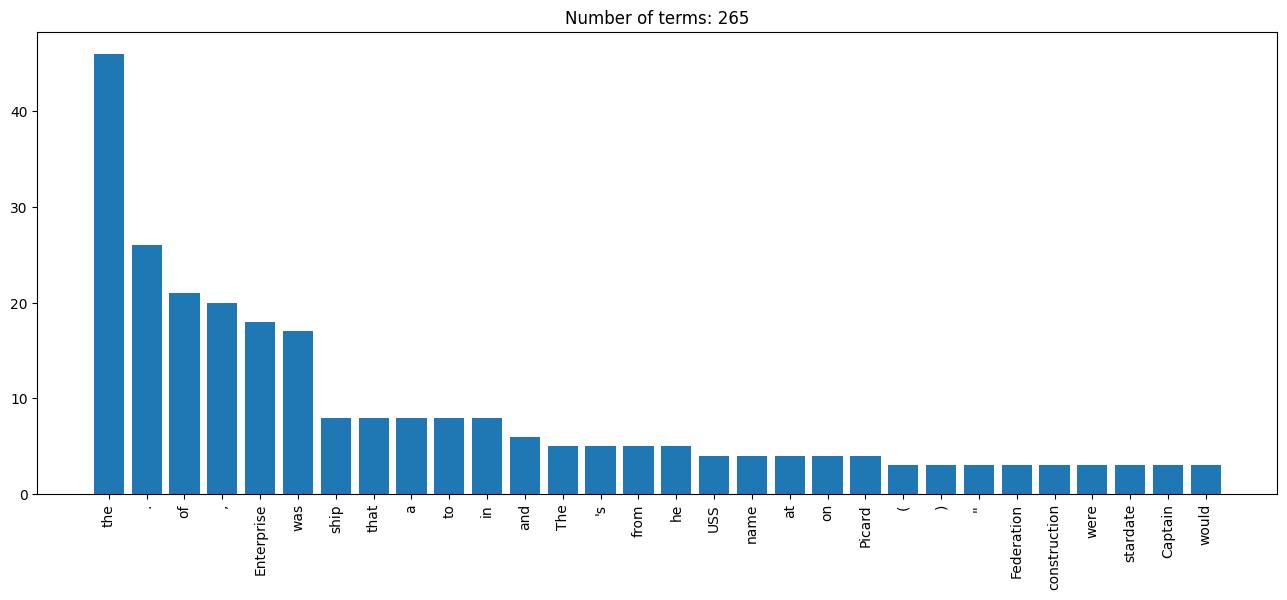

In [19]:
plot_words(tokens)

### Stop words

In [21]:
nltk.download('stopwords')
stopWords = nltk.corpus.stopwords.words('english')

stopWords.sort()
print(', '.join(stopWords))

a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, before, being, below, between, both, but, by, can, couldn, couldn't, d, did, didn, didn't, do, does, doesn, doesn't, doing, don, don't, down, during, each, few, for, from, further, had, hadn, hadn't, has, hasn, hasn't, have, haven, haven't, having, he, he'd, he'll, he's, her, here, hers, herself, him, himself, his, how, i, i'd, i'll, i'm, i've, if, in, into, is, isn, isn't, it, it'd, it'll, it's, its, itself, just, ll, m, ma, me, mightn, mightn't, more, most, mustn, mustn't, my, myself, needn, needn't, no, nor, not, now, o, of, off, on, once, only, or, other, our, ours, ourselves, out, over, own, re, s, same, shan, shan't, she, she'd, she'll, she's, should, should've, shouldn, shouldn't, so, some, such, t, than, that, that'll, the, their, theirs, them, themselves, then, there, these, they, they'd, they'll, they're, they've, this, those, through, to, too, under, until, up, v

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [22]:
# ANSWER
# NOTE: see the `.lower()` method applied to token
from nltk.tokenize import word_tokenize
tokens = word_tokenize(text_clean)
tokens_no_stop = [token for token in tokens if token.lower() not in stopWords]

In [23]:
## NLTK
i = 0
j = 0

print('i | with stop words without')
print('--| --------------- ------------')

# for all the tokens
while i < len(tokens):
    # same word
    if tokens[i] == tokens_no_stop[j]:
        print('%2d| %-15r %r' % (i+1, tokens[i], tokens_no_stop[j]))
        j += 1
    # not the same word
    else:
        print('%2d| %-15r' % (i+1, tokens[i]))

    # next word
    i += 1
    # break after the first sentence
    if tokens[i-1] == '.':
        break

i | with stop words without
--| --------------- ------------
 1| 'USS'           'USS'
 2| 'Enterprise'    'Enterprise'
 3| 'NCC1701D'      'NCC1701D'
 4| 'For'          
 5| 'five'          'five'
 6| 'hundred'       'hundred'
 7| 'years'         'years'
 8| 'every'         'every'
 9| 'ship'          'ship'
10| 'that'         
11| 'has'          
12| 'borne'         'borne'
13| 'the'          
14| 'name'          'name'
15| 'of'           
16| 'the'          
17| 'Enterprise'    'Enterprise'
18| 'has'          
19| 'become'        'become'
20| 'a'            
21| 'legend'        'legend'
22| 'This'         
23| 'one'           'one'
24| 'is'           
25| 'no'           
26| 'different'     'different'
27| 'The'          
28| 'USS'           'USS'
29| 'Enterprise'    'Enterprise'
30| 'NCC1701D'      'NCC1701D'
31| 'was'          
32| 'a'            
33| '24th'          '24th'
34| 'century'       'century'
35| 'United'        'United'
36| 'Federation'    'Federation'
37| 'of'        

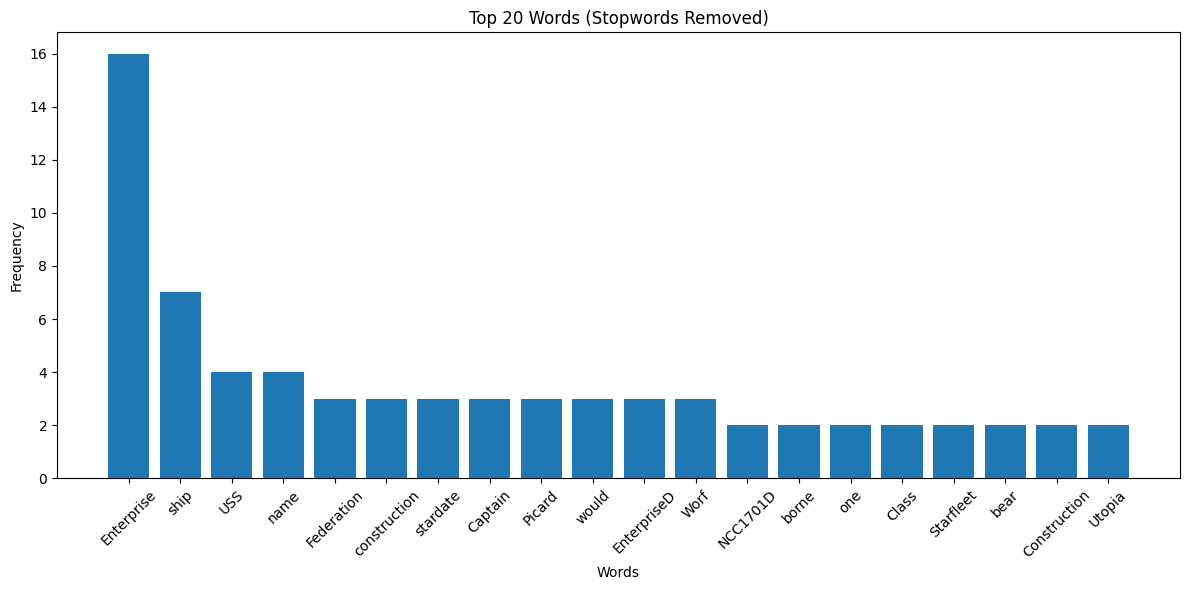

In [24]:
# Create plot of words without stopword
# ANSWER
# Count word frequencies
word_freq = Counter(tokens_no_stop)

# Get the top 20 most common words
most_common = word_freq.most_common(20)
words, counts = zip(*most_common)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Top 20 Words (Stopwords Removed)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Check Part of Speech

In [25]:
# define PoS
pos_list = {
    'CC':   'coordinating conjunction',
    'CD':   'cardinal digit',
    'DT':   'determiner',
    'EX':   'existential there (like: "there is" ... think of it like "there exists")',
    'FW':   'foreign word',
    'IN':   'preposition/subordinating conjunction',
    'JJ':   'adjective "big"',
    'JJR':  'adjective, comparative "bigger"',
    'JJS':  'adjective, superlative "biggest"',
    'LS':   'list marker 1)',
    'MD':   'modal could, will',
    'NN':   'noun, singular "desk"',
    'NNS':  'noun plural "desks"',
    'NNP':  'proper noun, singular "Harrison"',
    'NNPS': 'proper noun, plural "Americans"',
    'PDT':  'predeterminer "all the kids"',
    'POS':  'possessive ending parent"s',
    'PRP':  'personal pronoun I, he, she',
    'PRP$': 'possessive pronoun my, his, hers',
    'RB':   'adverb very, silently,',
    'RBR':  'adverb, comparative better',
    'RBS':  'adverb, superlative best',
    'RP':   'particle give up',
    'TO':   'to go "to" the store.',
    'UH':   'interjection errrrrrrrm',
    'VB':   'verb, base form take',
    'VBD':  'verb, past tense took',
    'VBG':  'verb, gerund/present participle taking',
    'VBN':  'verb, past participle taken',
    'VBP':  'verb, sing. present, non-3d take',
    'VBZ':  'verb, 3rd person sing. present takes',
    'WDT':  'wh-determiner which',
    'WP':   'wh-pronoun who, what',
    'WP$':  'possessive wh-pronoun whose',
    'WRB':  'wh-abverb where, when',
}

In [27]:
## nltk
nltk.download('averaged_perceptron_tagger_eng')
tagged = nltk.pos_tag(tokens)

for i, t in enumerate(tagged[:25]):
    print('%2d|%-12r : %-4s %s' % (i+1, t[0], t[1], (pos_list[t[1]] if t[1] in pos_list else '-')))

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


 1|'USS'        : NNP  proper noun, singular "Harrison"
 2|'Enterprise' : NNP  proper noun, singular "Harrison"
 3|'NCC1701D'   : NNP  proper noun, singular "Harrison"
 4|'For'        : IN   preposition/subordinating conjunction
 5|'five'       : CD   cardinal digit
 6|'hundred'    : CD   cardinal digit
 7|'years'      : NNS  noun plural "desks"
 8|'every'      : DT   determiner
 9|'ship'       : NN   noun, singular "desk"
10|'that'       : WDT  wh-determiner which
11|'has'        : VBZ  verb, 3rd person sing. present takes
12|'borne'      : VBN  verb, past participle taken
13|'the'        : DT   determiner
14|'name'       : NN   noun, singular "desk"
15|'of'         : IN   preposition/subordinating conjunction
16|'the'        : DT   determiner
17|'Enterprise' : NNP  proper noun, singular "Harrison"
18|'has'        : VBZ  verb, 3rd person sing. present takes
19|'become'     : VBN  verb, past participle taken
20|'a'          : DT   determiner
21|'legend'     : RBR  adverb, comparative b

### Stemming

In [28]:
## nltk
ps = nltk.porter.PorterStemmer()
stemmed = ' '.join([ps.stem(word) for word in text.split()])

### Lemmatisation

In [30]:
## nltk
nltk.download('wordnet')
wl = nltk.stem.WordNetLemmatizer()
lemma = ' '.join([wl.lemmatize(word) for word in text.split()])

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [31]:
## nltk
dot = stemmed.find('.') + 1
sl = stemmed[:dot].split()
dot = lemma.find('.') + 1
ll = lemma[:dot].split()

print('i | Stem           Lemma')
print('--| -------------- ------------')
for i, p in enumerate(zip(sl, ll)):
    print('%2d| %-12r   %-12r' % (i+1, p[0], p[1]))

i | Stem           Lemma
--| -------------- ------------
 1| 'uss'          'USS'       
 2| 'enterpris'    'Enterprise'
 3| '(ncc-1701-d)'   '(NCC-1701-D)'
 4| '"for'         '"For'      
 5| 'five'         'five'      
 6| 'hundr'        'hundred'   
 7| 'years,'       'years,'    
 8| 'everi'        'every'     
 9| 'ship'         'ship'      
10| 'that'         'that'      
11| 'ha'           'ha'        
12| 'born'         'borne'     
13| 'the'          'the'       
14| 'name'         'name'      
15| 'of'           'of'        
16| 'the'          'the'       
17| 'enterpris'    'Enterprise'
18| 'ha'           'ha'        
19| 'becom'        'become'    
20| 'a'            'a'         
21| 'legend.'      'legend.'   


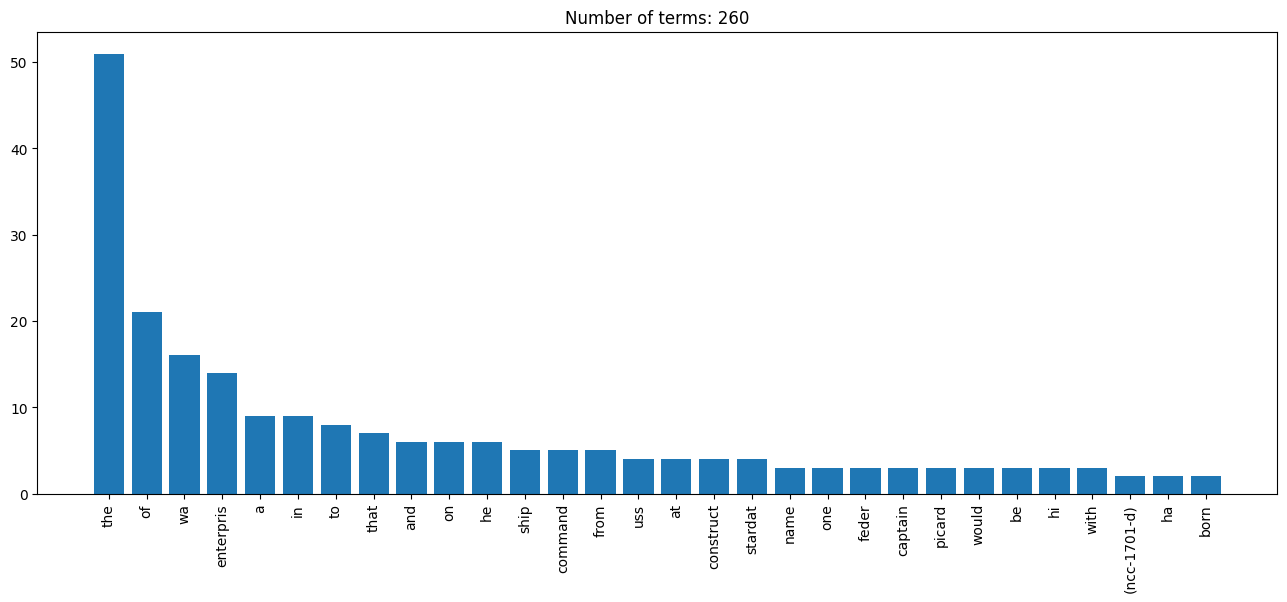

In [32]:
plot_words(stemmed.split())

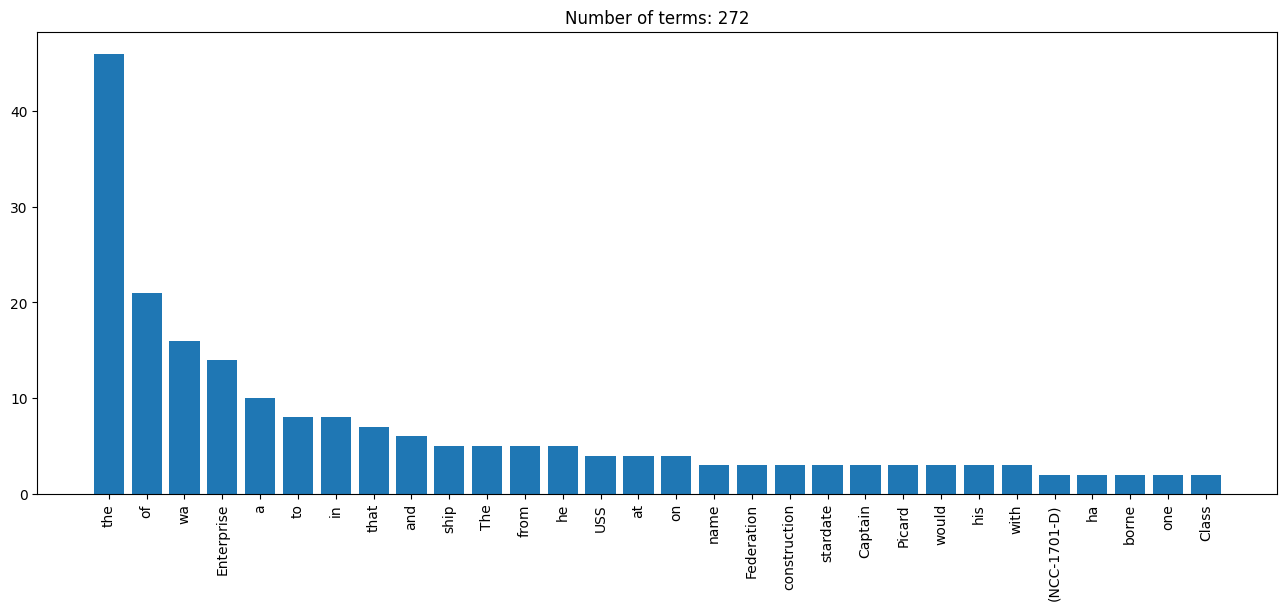

In [33]:
plot_words(lemma.split())

### Entity recognition

In [38]:
## nltk
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
entities = nltk.chunk.ne_chunk(tagged)

for e in entities:
    s = re.sub(r'[\(\)]', '', str(e))
    if s.find('/NNP') > 0:
        t = s.split()[0]
        n = ' '.join([re.sub(r'/NNP', '', x) for x in s.split()[1:]])
        print('%-12s: %s' % (t, n))

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


ORGANIZATION: USS Enterprise
ORGANIZATION: Enterprise
ORGANIZATION: USS Enterprise
PERSON      : United Federation
ORGANIZATION: Planets Galaxy
PERSON      : Starfleet
ORGANIZATION: Enterprise
ORGANIZATION: Federation
ORGANIZATION: Enterprise
ORGANIZATION: Battle
GPE         : Veridian
ORGANIZATION: Enterprise
ORGANIZATION: Utopia Planitia Fleet
PERSON      : Mars
ORGANIZATION: Solar
ORGANIZATION: Commander Orfil Quinteros
PERSON      : Brahms
ORGANIZATION: Enterprises
ORGANIZATION: USS
ORGANIZATION: Utopia
PERSON      : Walter Pierce
PERSON      : Marla Finn
PERSON      : William Hodges
PERSON      : Pierce
ORGANIZATION: Enterprise
PERSON      : Mars
ORGANIZATION: Enterprise
FACILITY    : Earth Station
ORGANIZATION: McKinley Captain
ORGANIZATION: JeanLuc Picard
ORGANIZATION: Rear Admiral Norah Satie Legacy
PERSON      : Riker
ORGANIZATION: Enterprise
PERSON      : Picard
ORGANIZATION: EnterpriseD
ORGANIZATION: Enterprise
PERSON      : Deep Space
PERSON      : Starfleet Station
PERSON 



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



